# Rapport d'étude de NLF - Tom LE BER (22308482) & Tony PEROTTINO (22303877)

## I. Initialisation

### 1. Monter le Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Définir les chemins

In [ ]:
import os

BASE_DIRECTORY = "/content/drive/MyDrive/02 - Cours/01 - MIDL/Stage MIDL" # A remplacer par le chemin vers le dossier de votre Google Drive contenant la vidéo "video.mp4" et de dossier "frames" contenant toutes les frames de la vidéo.
VIDEO_PATH = os.path.join(BASE_DIRECTORY, "video.mp4")
FRAMES_DIRECTORY = os.path.join(BASE_DIRECTORY, "frames")

# Créer le dossier "frames", s'il n'existe pas déjà :
os.makedirs(FRAMES_DIRECTORY, exist_ok=True)

### 3. Extraire toutes les images de la vidéo

In [ ]:
# Extraire toutes les frames :
if not (os.path.isdir(FRAMES_DIRECTORY) and os.listdir(FRAMES_DIRECTORY)):
    !ffmpeg -i "{VIDEO_PATH}" "{FRAMES_DIRECTORY}/frame_%04d.png"

## II. Importer NLF

### 1. Cloner le repo NLF (`https://github.com/isarandi/nlf.git`)

In [ ]:
# Cloner le repo NLF dans /content :
if not os.path.exists("/content/nlf"):
    %cd /content
    !git clone https://github.com/isarandi/nlf.git

/content
Cloning into 'nlf'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (304/304), done.
remote: Compressing objects: 100% (221/221), done.
remote: Total 304 (delta 139), reused 237 (delta 82), pack-reused 0 (from 0)
Receiving objects: 100% (304/304), 403.72 KiB | 20.19 MiB/s, done.
Resolving deltas: 100% (139/139), done.


### 2. Télécharger le `TorchScript`

In [ ]:
%cd /content/nlf

# Créer le dossier pour le modèle et télécharger le TorchScript :
!mkdir -p models
!wget -q -O models/nlf_l_multi.torchscript https://bit.ly/nlf_l_pt # Le lien pointe vers le modèle TorchScript NLF-L publié dans les releases du repo.

/content/nlf


## III. Exécution de `NLF`

### 1. Initialisation des paramètres et chargement du modèle

Dans cette partie, nous appliquons le modèle NLF à la vidéo de pole-dance.  
L’objectif est de :
1. Charger le modèle NLF (version TorchScript) sur GPU.
2. Définir une fonction d’inférence sur une image unique (frame).
3. Appliquer NLF à un sous-ensemble de frames de la vidéo.
4. Visualiser et analyser qualitativement les prédictions (joints 2D et 3D).

Ensuite, chargeons la version TorchScript du modèle NLF (`nlf_l_multi.torchscript`), qui a été téléchargée dans le dossier `/content/nlf/models/` depuis les Releases du dépôt GitHub.

In [ ]:
import glob
import numpy as np

# Paramètres d'expérience pour NLF :
MAX_FRAMES = 5000 # Nombre maximum de frames à traiter (pour l'étude).
FRAME_STEP = 1 # 1 = toutes les frames, 2 = une frame sur deux, etc.

# FRAMES_DIRECTORY et BASE_DIRECTORY sont supposés définis dans la partie précédente :
frame_paths_all = sorted(glob.glob(os.path.join(FRAMES_DIRECTORY, "frame_*.png")))

# Sous-échantillonnage éventuel :
frame_paths = frame_paths_all[::FRAME_STEP]

# Limitation au nombre maximum de frames :
frame_paths = frame_paths[:MAX_FRAMES]

print(f"Nombre total de frames extraites : {len(frame_paths_all)}")
print(f"Nombre de frames utilisées pour NLF : {len(frame_paths)}")

Nombre total de frames extraites : 1329
Nombre de frames utilisées pour NLF : 1329


In [ ]:
%cd /content/nlf

import torch
import torchvision
from tqdm.auto import tqdm

# Sélection du "device" :
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# Chemin vers le modèle TorchScript (doit déjà avoir été téléchargé) :
MODEL_PATH = "models/nlf_l_multi.torchscript"

# Chargement du modèle :
model = torch.jit.load(MODEL_PATH, map_location=device).eval()

print("Modèle NLF chargé avec succès.")

/content/nlf
Device utilisé : cuda
Modèle NLF chargé avec succès.


### 2. Définition de la fonction `run_nlf_on_image`

Nous définissons une fonction `run_nlf_on_image(img_path)` qui :
1. Charge une image de frame depuis son chemin.
2. La met au bon format pour NLF (batch de taille 1).
3. Appelle `model.detect_smpl_batched(...)`.
4. Récupère les joints 2D et 3D pour **la première personne** détectée.
5. Retourne un dictionnaire Python sérialisable (listes plutôt que tenseurs).

Nous considérons qu’il n’y a qu’une seule personne (la pole-danseuse) dans la scène.

In [ ]:
def run_nlf_on_image(img_path: str):
    """
    Applique NLF à une image unique.
    Retourne un dictionnaire contenant :
      - frame : nom de fichier de la frame,
      - has_person : booléen indiquant si une personne a été détectée,
      - joints2d : liste [J, 2] des coordonnées 2D des joints (en pixels),
      - joints3d : liste [J, 3] des coordonnées 3D des joints (repère caméra).
    """
    # Charger l'image (C,H,W), uint8 :
    image = torchvision.io.read_image(img_path).to(device)

    # Ajouter la dimension batch : [1, C, H, W]
    frame_batch = image.unsqueeze(0)

    # Inférence NLF :
    with torch.inference_mode():
        pred = model.detect_smpl_batched(frame_batch)

    # pred["joints2d"] et pred["joints3d"] sont des listes (une entrée par élément du batch) :
    joints2d_batch = pred["joints2d"][0]
    joints3d_batch = pred["joints3d"][0]

    # Si le modèle renvoie [num_persons, J, 2] ou [num_persons, J, 3] :
    if joints2d_batch.ndim == 3:
        # Si aucune personne détectée :
        if joints2d_batch.shape[0] == 0:
            return {
                "frame": os.path.basename(img_path),
                "has_person": False,
                "joints2d": None,
                "joints3d": None,
            }
        # On prend la première personne :
        j2d = joints2d_batch[0] # [J, 2]
        j3d = joints3d_batch[0] # [J, 3]
    else:
        # Cas où le modèle renvoie directement [J, 2] / [J, 3] :
        j2d = joints2d_batch
        j3d = joints3d_batch

    # Conversion en numpy, puis en listes Python :
    j2d_np = j2d.detach().cpu().numpy()
    j3d_np = j3d.detach().cpu().numpy()

    result = {
        "frame": os.path.basename(img_path),
        "has_person": True,
        "joints2d": j2d_np.tolist(), # [J, 2]
        "joints3d": j3d_np.tolist(), # [J, 3]
    }
    return result

### 3. Inférence sur un lot de frames

Nous appliquons maintenant `run_nlf_on_image` à un sous-ensemble de frames :
- Les chemins de frames sont définis dans la cellule de paramètres (`frame_paths`).
- Nous mesurons le **temps d'inférence** par frame.
- Nous stockons les résultats dans une liste `results`, chaque entrée correspondant à une frame.

À la fin, nous sauvegardons les résultats dans un fichier JSON situé dans `BASE_DIRECTORY`.

In [ ]:
import time
import json

results = []
times = []

print(f"Lancement de NLF sur {len(frame_paths)} frames.")

for img_path in tqdm(frame_paths, desc="NLF inference"):
    t0 = time.perf_counter()
    res = run_nlf_on_image(img_path)
    t1 = time.perf_counter()

    res["infer_time"] = t1 - t0 # Temps pour cette frame.
    results.append(res)
    times.append(t1 - t0)

times = np.array(times)

print(f"Nombre total de résultats : {len(results)}")
print(f"Temps moyen par frame : {times.mean()*1000:.1f} ms")
print(f"FPS approximatif : {1.0 / times.mean():.2f}")

# Sauvegarde des résultats dans un JSON :
output_path = os.path.join(BASE_DIRECTORY, "nlf_results_subset.json")
with open(output_path, "w") as f:
    json.dump(results, f)

print(f"Résultats sauvegardés dans : {output_path}")

Lancement de NLF sur 1329 frames.


NLF inference:   0%|          | 0/1329 [00:00<?, ?it/s]

Nombre total de résultats : 1329
Temps moyen par frame : 309.7 ms
FPS approximatif : 3.23
Résultats sauvegardés dans : /content/drive/MyDrive/02 - Cours/01 - MIDL/Stage MIDL/nlf_results_subset.json


### 4. Visualisation qualitative de NLF

Nous proposons plusieurs visualisations :
1. **Overlay 2D des joints sur une frame** (qualité instantanée de la pose).
2. **Mosaïque de plusieurs frames** avec leurs joints 2D.
3. **Évolution temporelle de la profondeur (Z) d’un joint donné**.
4. **Visualisation 3D d’une pose** à partir de `joints3d`.

Ces visualisations serviront de base à l’analyse qualitative de NLF dans la section suivante.

#### A. Overlay 2D sur une frame

Frames avec personne détectée : 1263


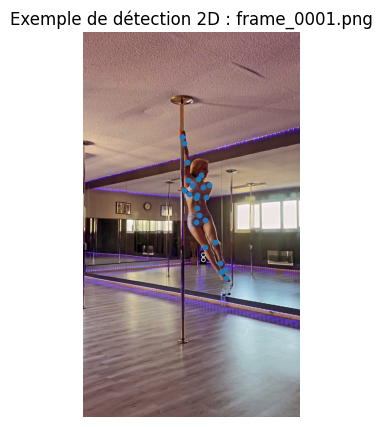

In [ ]:
import matplotlib.pyplot as plt

# Filtrer uniquement les frames où une personne a été détectée :
valid_results = [r for r in results if r["has_person"]]

print(f"Frames avec personne détectée : {len(valid_results)}")

if len(valid_results) == 0:
    raise ValueError("Aucune personne détectée dans les frames sélectionnées.")

# On prend un exemple (par ex. la première) :
sample = valid_results[0]
frame_name = sample["frame"]
j2d = np.array(sample["joints2d"]) # [J, 2]

img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy() # [H,W,C]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.scatter(j2d[:, 0], j2d[:, 1], s=10)
plt.title(f"Exemple de détection 2D : {frame_name}")
plt.axis("off")
plt.show()

#### B. Mosaïque de plusieurs frames avec joints 2D

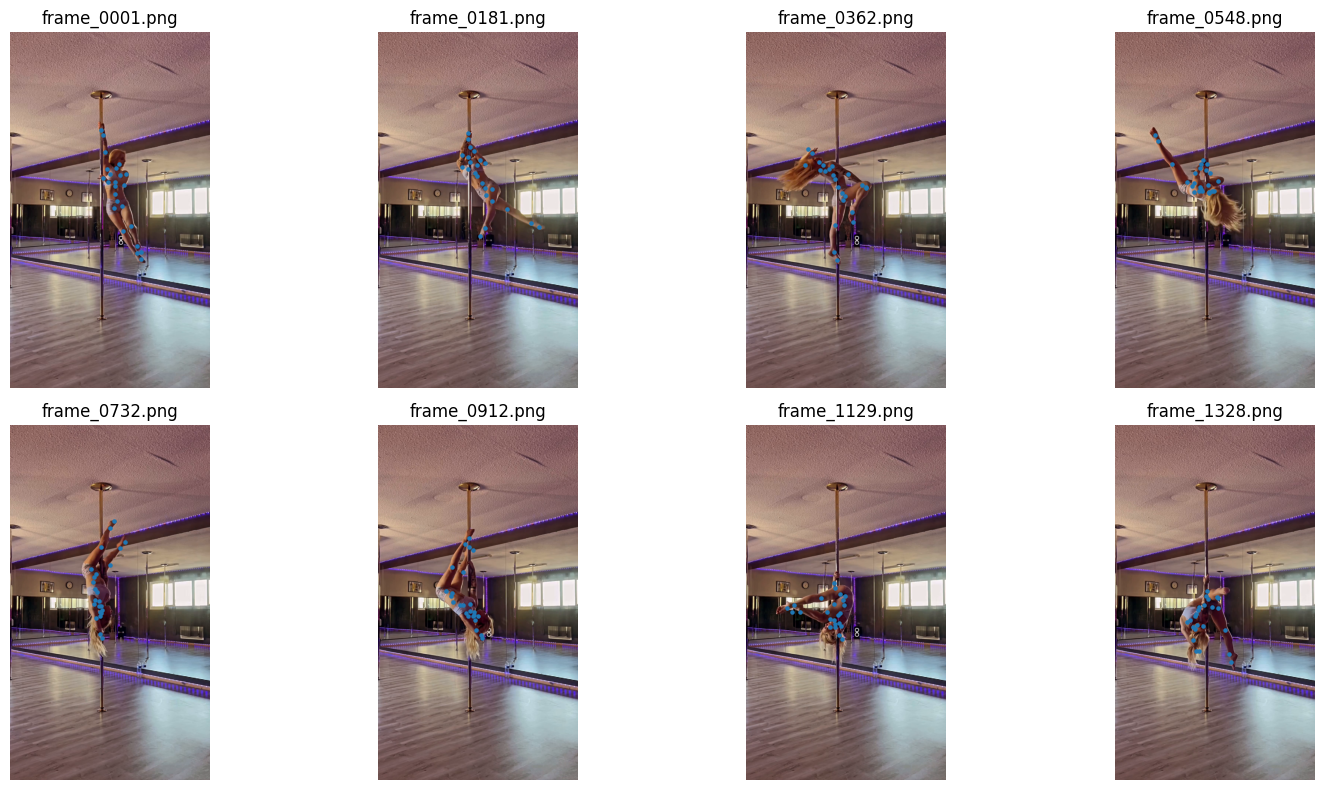

In [ ]:
# Nombre d'exemples à afficher dans la mosaïque :
num_examples = min(8, len(valid_results))

# On prend des indices uniformément répartis dans la séquence des frames :
indices = np.linspace(0, len(valid_results) - 1, num_examples, dtype=int)

cols = 4
rows = int(np.ceil(num_examples / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, idx in enumerate(indices, start=1):
    res = valid_results[idx]
    frame_name = res["frame"]
    j2d = np.array(res["joints2d"])

    img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
    img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy()

    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.scatter(j2d[:, 0], j2d[:, 1], s=5)
    ax.set_title(frame_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### C. Évolution de la profondeur Z d’un joint

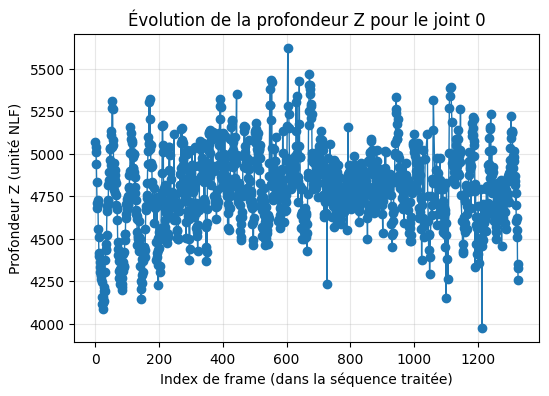

In [ ]:
# Indice du joint étudié :
JOINT_INDEX = 0 # 0 = tête.

z_vals = []
frames_idx = []

for i, res in enumerate(results):
    if not res["has_person"]:
        continue
    j3d = np.array(res["joints3d"]) # [J, 3]
    if j3d.shape[0] <= JOINT_INDEX:
        continue
    z_vals.append(j3d[JOINT_INDEX, 2])
    frames_idx.append(i)

plt.figure(figsize=(6, 4))
plt.plot(frames_idx, z_vals, marker="o", linestyle="-", linewidth=1)
plt.xlabel("Index de frame (dans la séquence traitée)")
plt.ylabel("Profondeur Z (unité NLF)")
plt.title(f"Évolution de la profondeur Z pour le joint {JOINT_INDEX}")
plt.grid(True, alpha=0.3)
plt.show()

#### D. Visualisation 3D d’une pose

Frames avec personne détectée : 1263


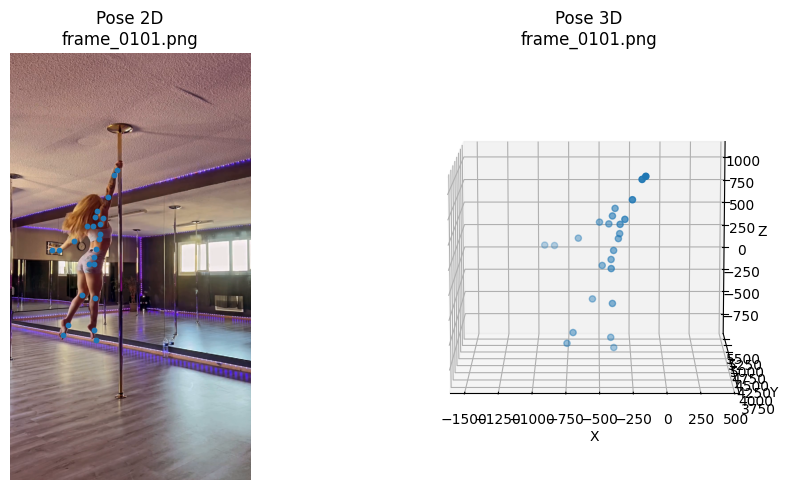

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Affichage 3D.

# On vérifie qu'on a bien des résultats valides :
valid_results = [r for r in results if r["has_person"]]
print(f"Frames avec personne détectée : {len(valid_results)}")

if len(valid_results) == 0:
    raise ValueError("Aucune personne détectée dans les frames sélectionnées.")

# Choix de l'index de frame à visualiser :
FRAME_INDEX_FOR_3D_VIEW = 100

sample = valid_results[FRAME_INDEX_FOR_3D_VIEW]
frame_name = sample["frame"]
j2d = np.array(sample["joints2d"]) # [J, 2]
j3d = np.array(sample["joints3d"]) # [J, 3]

# Chargement de l'image correspondante :
img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy() # [H,W,C]

# Remapping des axes pour que la pose 3D "colle" mieux à l'image :
    # X_vis : gauche/droite
    # Y_vis : profondeur (distance caméra)
    # Z_vis : hauteur (haut/bas) -> on prend -Y pour que le haut soit "vers le haut"
X_vis = j3d[:, 0]
Y_vis = j3d[:, 2]
Z_vis = -j3d[:, 1]

# Petite fonction pour avoir des axes isotropes (squelette non écrasé) :
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max([x_range, y_range, z_range]) / 2.0

    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)

    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

# Affichage des figures combinées en 2 colonnes :
fig = plt.figure(figsize=(10, 5))
    # Figure 1 (image + joints 2D) :
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img)
ax1.scatter(j2d[:, 0], j2d[:, 1], s=10)
ax1.set_title(f"Pose 2D\n{frame_name}")
ax1.axis("off")
    # Figure 2 (visualisation 3D) :
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_vis, Y_vis, Z_vis)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_title(f"Pose 3D\n{frame_name}")
ax2.view_init(elev=10, azim=-90) # Vue "de face" pour que ça ressemble à la projection de l'image.
ax2.grid(True, alpha=0.3) # Grille moins prononcée.
set_axes_equal(ax2)

plt.tight_layout()
plt.show()

## IV. Analyse qualitative de NLF

### IV.1 Protocole expérimental

Dans cette section, nous analysons les résultats produits par NLF sur la vidéo de pole dance.

Le protocole d'expérience est le suivant :
- La vidéo source est découpée en images individuelles (frames) via `ffmpeg`.
- Un sous-ensemble de ces frames est sélectionné selon deux paramètres :
  - `MAX_FRAMES` : nombre maximal de frames traitées,
  - `FRAME_STEP` : pas d'échantillonnage (par exemple 1 = toutes les frames, 2 = une frame sur deux, etc.).
- Pour chaque frame sélectionnée, le modèle NLF (version TorchScript pré-entraînée) est appliqué :
  - le modèle renvoie notamment les positions des joints en 2D (`joints2d`) et en 3D (`joints3d`),
  - ainsi qu’un indicateur `has_person` indiquant si une personne a été détectée,
  - et nous mesurons le temps d’inférence `infer_time` pour chaque frame.

Les résultats sont stockés dans la liste Python `results`, chaque élément correspondant à une frame traitée.

### IV.2 Taux de détection

Nous commençons par quantifier la capacité de NLF à détecter la danseuse sur les frames traitées.
Pour chaque frame, l’indicateur `has_person` vaut `True` lorsque NLF estime au moins une pose humaine,
et `False` dans le cas contraire.

In [ ]:
import numpy as np

# Analyse du nombre d'images sans personne détectée :
num_frames = len(results)
num_detect = sum(r["has_person"] for r in results)
detect_rate = num_detect / num_frames if num_frames > 0 else 0.0

print(f"Nombre de frames traitées : {num_frames}")
print(f"Nombre de frames avec une personne détectée : {num_detect}")
print(f"Taux de détection : {detect_rate*100:.1f} %")

# Analyse des "trous" de détection (séquences consécutives sans personne détectée) :
gaps = []
current_gap = 0

for r in results:
    if not r["has_person"]:
        current_gap += 1
    elif current_gap > 0:
        gaps.append(current_gap)
        current_gap = 0

if current_gap > 0:
    gaps.append(current_gap)

print(f"\nNombre de séquences consécutives sans détection : {len(gaps)}")
print(f"Longueur maximale d'une séquence sans détection (en frames) : {max(gaps) if gaps else 0}")
print(f"Longueur moyenne des séquences sans détection (en frames) : {np.mean(gaps) if gaps else 0}")

Nombre de frames traitées : 1329
Nombre de frames avec une personne détectée : 1263
Taux de détection : 95.0 %

Nombre de séquences consécutives sans détection : 35
Longueur maximale d'une séquence sans détection (en frames) : 6
Longueur moyenne des séquences sans détection (en frames) : 1.8857142857142857


Les valeurs affichées ci-dessus donnent une première mesure de la robustesse de NLF
sur cette séquence vidéo.
- Le **taux de détection** indique la proportion de frames pour lesquelles au moins une pose
  est estimée. Un taux proche de 100 % signifie que le modèle suit pratiquement en continu
  la danseuse, tandis qu’un taux plus faible traduit des pertes de suivi liées, par exemple,
  à des poses extrêmes, des occlusions par la barre ou un flou de mouvement important.
- L’analyse des **séquences consécutives sans détection** (nombre de “trous” et longueur maximale)
  permet de distinguer :
  - des pertes ponctuelles de 1–2 frames, généralement peu problématiques pour un traitement
    vidéo ultérieur car elles peuvent être lissées temporellement ;
  - des absences plus longues (plusieurs dizaines de frames), qui peuvent en revanche casser
    la cohérence du suivi et poser problème pour une ré-insertion réaliste du corps dans un
    environnement de synthèse.

Ces indicateurs seront utiles pour juger la viabilité de NLF dans un pipeline où l’on souhaite
suivre précisément un sujet humain dans des conditions de prise de vue dégradées.

### IV.3 Temps d’inférence

Nous nous intéressons maintenant au **coût de calcul** de NLF, mesuré par le temps d’inférence
par frame. Pour chaque frame traitée, la variable `infer_time` contient la durée (en secondes)
nécessaire à une passe du modèle sur le matériel utilisé (GPU Colab).

Temps moyen par frame : 309.7 ms
Temps médian par frame : 186.8 ms
FPS approximatif (1 / temps moyen) : 3.23


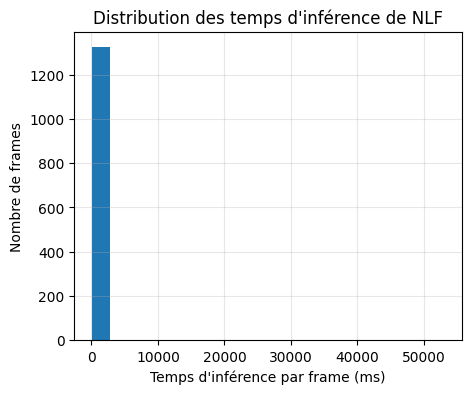

In [ ]:
import matplotlib.pyplot as plt

times = np.array([r["infer_time"] for r in results])

print(f"Temps moyen par frame : {times.mean()*1000:.1f} ms")
print(f"Temps médian par frame : {np.median(times)*1000:.1f} ms")
print(f"FPS approximatif (1 / temps moyen) : {1.0 / times.mean():.2f}")

plt.figure(figsize=(5, 4))
plt.hist(times * 1000, bins=20)
plt.xlabel("Temps d'inférence par frame (ms)")
plt.ylabel("Nombre de frames")
plt.title("Distribution des temps d'inférence de NLF")
plt.grid(True, alpha=0.3)
plt.show()

Le temps d’inférence moyen (et médian) permet d’estimer le **débit effectif** du modèle,
c’est-à-dire le nombre d’images par seconde (FPS) que l’on peut traiter dans les conditions
de l’expérience (taille des images, GPU disponible sur Colab, etc.).
- Si le nombre de FPS est de l’ordre de quelques images par seconde, NLF est adapté
  à un traitement **off-line** de séquences vidéo (post-traitement, analyse de données,
  génération de nouvelles vues).
- Si les FPS sont nettement plus élevés (par exemple au-delà de 15–20 FPS), un usage
  **quasi temps réel** devient envisageable, sous réserve que le reste du pipeline
  (pré- et post-traitement) reste léger.
- À l’inverse, si le temps par frame est très élevé, il faudra éventuellement
  envisager des optimisations (sous-échantillonnage temporel, réduction de la
  résolution d’entrée, modèles plus petits, etc.) ou accepter que NLF soit réservé
  à des cas d’usage où le temps de calcul n’est pas critique.

La distribution des temps d’inférence (histogramme) permet également de repérer
d’éventuelles **queues lourdes** (quelques frames beaucoup plus coûteuses),
par exemple dues à des surcharges temporaires du système ou à des variations
dans la taille effective de l’image.

### IV.4 Cas limites (frames sans détection)

Pour mieux comprendre les situations dans lesquelles NLF échoue à détecter une personne,
nous visualisons quelques frames pour lesquelles `has_person` vaut `False`.
Cela permet d’identifier des motifs récurrents (occlusions, poses extrêmes, sortie du champ,
variations d’éclairage, etc.) qui sont susceptibles de poser problème au modèle.

Nombre total de frames sans détection : 66


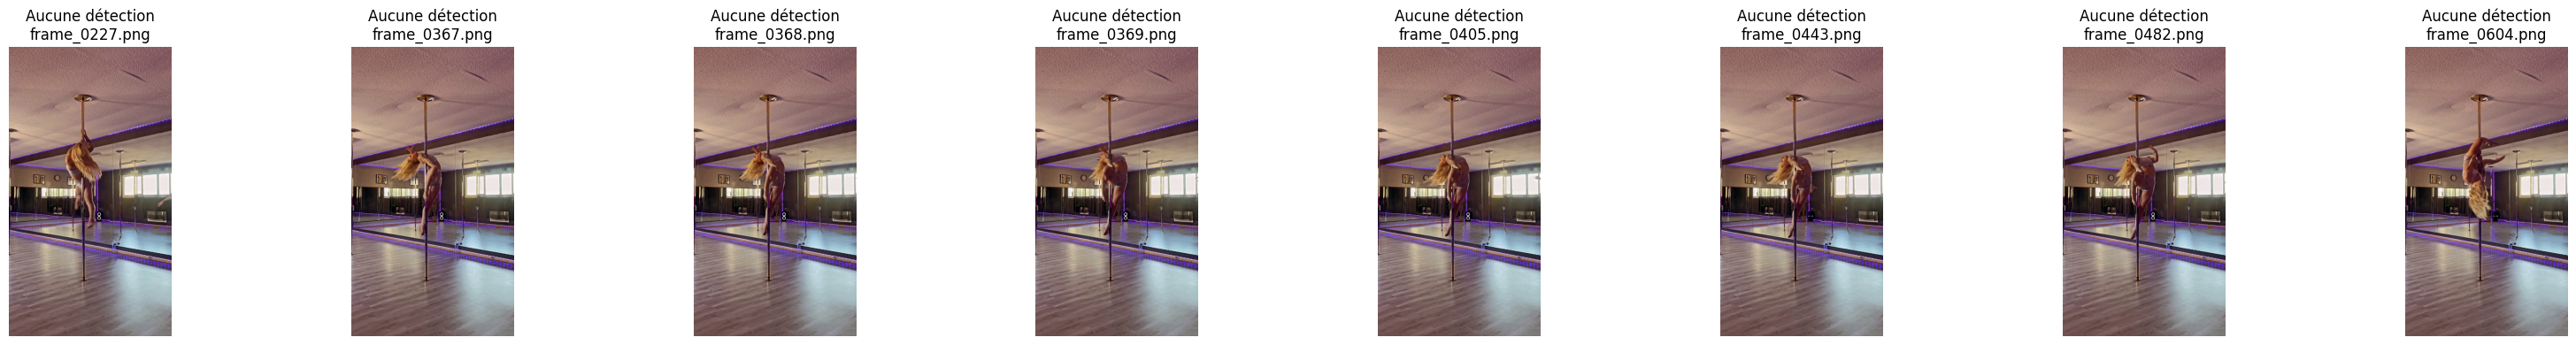

In [ ]:
# Sélection des frames sans détection :
no_person_results = [r for r in results if not r["has_person"]]
num_no_person = len(no_person_results)

print(f"Nombre total de frames sans détection : {num_no_person}")

# Nombre d'exemples à afficher (au maximum 8) :
num_examples = min(8, num_no_person)

if num_examples == 0:
    print("Aucune frame sans détection à afficher.")
else:
    plt.figure(figsize=(4 * num_examples, 4))

    for i, res in enumerate(no_person_results[:num_examples], start=1):
        frame_name = res["frame"]
        img_path = os.path.join(FRAMES_DIRECTORY, frame_name)
        img = torchvision.io.read_image(img_path).permute(1, 2, 0).cpu().numpy()

        ax = plt.subplot(1, num_examples, i)
        ax.imshow(img)
        ax.set_title(f"Aucune détection\n{frame_name}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Les images affichées ci-dessus illustrent des **situations typiques d’échec** pour NLF,
dans le contexte spécifique de la vidéo de danse étudiée.

On observe en général 2-3 types de scénarios :
- **Occlusions partielles ou complètes** par la barre ou d’autres éléments du décor,
  qui cachent des parties importantes du corps et rendent la pose ambiguë.
- **Poses très extrêmes** (forte extension des bras, torsion du tronc, inversions),
  qui s’éloignent des postures présentes dans les jeux de données de pré-entraînement
  et peuvent dégrader la confiance du modèle.
- Éventuellement, des effets de **flou de mouvement** (?) ou de contraste difficile,
  en particulier lorsque la danseuse se déplace rapidement ou que l’éclairage est hétérogène.

Ces cas limites fournissent des indications précieuses sur les conditions de filmage
dans lesquelles NLF risque de perdre le suivi. Ils suggèrent également que, pour une
utilisation opérationnelle (par exemple sur des vidéos embarquées par un drone),
il serait souhaitable de coupler NLF à des mécanismes de suivi temporel ou à des
heuristiques de récupération lorsque la détection disparaît temporairement.

### IV.5 Cohérence et stabilité temporelle en 3D

Au-delà de la détection frame par frame, il est important d’évaluer la **stabilité temporelle**
des poses 3D estimées. Dans cette sous-section, nous suivons :
1. La trajectoire d’un joint donné (par exemple le bassin ou la tête) au cours du temps.
2. La variation moyenne de la position 3D de ce joint d’une frame à la suivante (mesure simple du “jitter”).

Ces indicateurs donnent une idée de la fluidité du mouvement reconstruit, ce qui est crucial
pour des applications où l’on souhaite ré-animer le personnage dans un nouvel environnement.

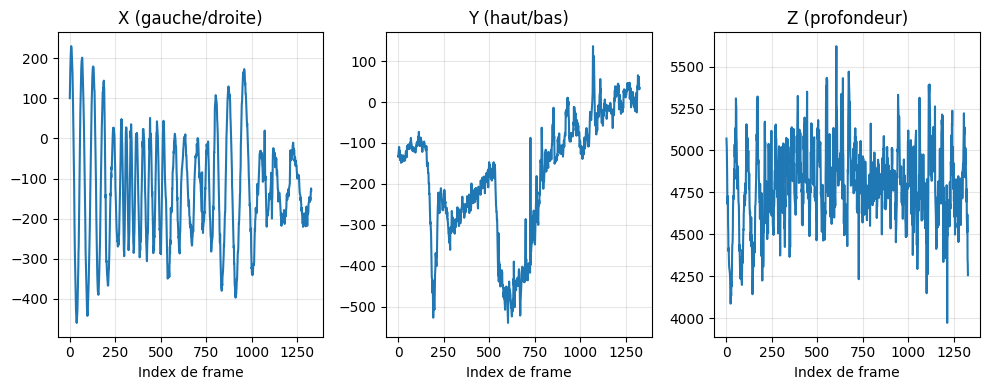

In [ ]:
# Indice du joint étudié (à adapter après inspection de la convention NLF) :
JOINT_INDEX = 0 # 0 = tête.

xs, ys, zs, ts = [], [], [], []

for i, r in enumerate(results):
    if not r["has_person"]:
        continue
    j3d = np.array(r["joints3d"]) # [J, 3]
    if j3d.shape[0] <= JOINT_INDEX:
        continue
    xs.append(j3d[JOINT_INDEX, 0])
    ys.append(j3d[JOINT_INDEX, 1])
    zs.append(j3d[JOINT_INDEX, 2])
    ts.append(i)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.plot(ts, xs)
plt.title("X (gauche/droite)")
plt.xlabel("Index de frame")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(ts, ys)
plt.title("Y (haut/bas)")
plt.xlabel("Index de frame")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(ts, zs)
plt.title("Z (profondeur)")
plt.xlabel("Index de frame")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les trois courbes ci-dessus représentent l’évolution des coordonnées 3D d’un joint donné
(en général un point relativement stable comme le bassin ou la tête) au cours des frames.

- Une trajectoire **relativement lisse** dans les trois directions indique que NLF reconstruit
  un mouvement cohérent, ce qui est favorable à la ré-utilisation des poses dans un contexte
  d’animation ou de simulation.
- Des **sauts brusques** entre certaines frames peuvent révéler des problèmes de stabilité :
  inversion de gauche/droite, ambiguïtés de profondeur, ou changements soudains de la pose
  estimée dans les cas où la géométrie est difficile à interpréter.

Ces observations doivent être mises en relation avec les cas limites identifiés dans la
section précédente : on s’attend à ce que les segments temporels problématiques (occlusions,
sorties de champ) se traduisent par des irrégularités dans les trajectoires 3D.

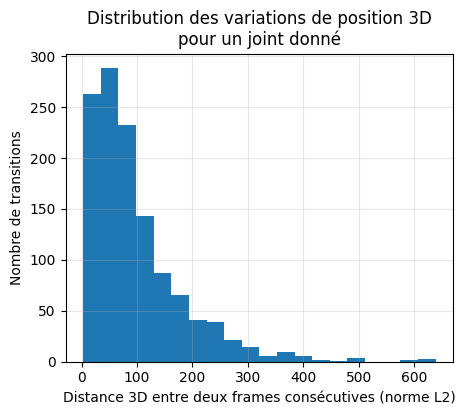

Variation moyenne (L2) entre frames : 99.13162861419312
Variation 95e percentile : 265.1227486199661


In [ ]:
# Mesure de la variation entre deux frames consécutives pour le même joint :
JOINT_INDEX = 0 # 0 = tête.

dists = []
prev = None

for r in results:
    if not r["has_person"]:
        prev = None
        continue
    j3d = np.array(r["joints3d"])
    if j3d.shape[0] <= JOINT_INDEX:
        continue
    cur = j3d[JOINT_INDEX] # [3]
    if prev is not None:
        d = np.linalg.norm(cur - prev)
        dists.append(d)
    prev = cur

plt.figure(figsize=(5, 4))
plt.hist(dists, bins=20)
plt.xlabel("Distance 3D entre deux frames consécutives (norme L2)")
plt.ylabel("Nombre de transitions")
plt.title("Distribution des variations de position 3D\npour un joint donné")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Variation moyenne (L2) entre frames : {np.mean(dists) if dists else "N/A"}")
print(f"Variation 95e percentile : {np.percentile(dists, 95) if dists else "N/A"}")

L’histogramme des distances 3D entre deux frames consécutives fournit une mesure simple
du **“jitter”** sur le joint considéré :

- Si la majorité des distances est faible, la pose 3D évolue de manière régulière
  et le mouvement reconstruit apparaît fluide.
- Des valeurs élevées (en particulier dans les percentiles supérieurs) traduisent
  des discontinuités marquées, susceptibles de générer des artefacts visibles lors
  de la re-projection ou de l’animation du squelette.

Cette analyse reste volontairement simple, mais elle donne un premier ordre de grandeur
de la stabilité temporelle de NLF dans ce scénario. Des travaux futurs pourraient s’appuyer
sur ces mesures pour concevoir des algorithmes de lissage temporel ou pour comparer
plus systématiquement NLF à d’autres approches de pose 3D, comme MMPose ou des méthodes
basées sur des modèles implicitement temporalisés.

## V. Conclusion / Viabilité

...

In [ ]:
...

Ellipsis